In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# LOAD DATA HASIL KMEANS
df = pd.read_excel("data/data_hasil_kmeans.xlsx")

In [3]:
fitur = [
    'Besar Pinjaman',
    'Sisa Pinjaman',
    'Angsuran Pokok',
    'Tenor',
    'Tunggakan Maksimum'
]

In [4]:
# TARGET
y = df['Risiko']

In [5]:
X1 = df[fitur]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y
)

rf1 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf1.fit(X_train1, y_train1)

# Prediksi
y_pred1 = rf1.predict(X_test1)

# Accuracy
train_acc1 = rf1.score(X_train1, y_train1)
test_acc1 = rf1.score(X_test1, y_test1)

print("=== BASELINE ===")
print("Train Accuracy:", train_acc1)
print("Test Accuracy :", test_acc1)
print(classification_report(y_test1, y_pred1))
print(confusion_matrix(y_test1, y_pred1))



=== BASELINE ===
Train Accuracy: 1.0
Test Accuracy : 0.9894736842105263
              precision    recall  f1-score   support

      Rendah       0.99      1.00      0.99        80
      Sedang       1.00      0.80      0.89         5
      Tinggi       1.00      1.00      1.00        10

    accuracy                           0.99        95
   macro avg       1.00      0.93      0.96        95
weighted avg       0.99      0.99      0.99        95

[[80  0  0]
 [ 1  4  0]
 [ 0  0 10]]


In [6]:
X2 = df[fitur + ['Cluster']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)

rf2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf2.fit(X_train2, y_train2)

# Prediksi
y_pred2 = rf2.predict(X_test2)

# Accuracy
train_acc2 = rf2.score(X_train2, y_train2)
test_acc2 = rf2.score(X_test2, y_test2)

print("\n=== HYBRID ===")
print("Train Accuracy:", train_acc2)
print("Test Accuracy :", test_acc2)
print(classification_report(y_test2, y_pred2))
print(confusion_matrix(y_test2, y_pred2))


=== HYBRID ===
Train Accuracy: 1.0
Test Accuracy : 1.0
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        80
      Sedang       1.00      1.00      1.00         5
      Tinggi       1.00      1.00      1.00        10

    accuracy                           1.00        95
   macro avg       1.00      1.00      1.00        95
weighted avg       1.00      1.00      1.00        95

[[80  0  0]
 [ 0  5  0]
 [ 0  0 10]]


In [7]:
print("\n=== PERBANDINGAN ===")
print("Baseline Train:", train_acc1)
print("Baseline Test :", test_acc1)

print("Hybrid Train :", train_acc2)
print("Hybrid Test  :", test_acc2)


=== PERBANDINGAN ===
Baseline Train: 1.0
Baseline Test : 0.9894736842105263
Hybrid Train : 1.0
Hybrid Test  : 1.0


In [8]:


importance = pd.DataFrame({
    'Fitur': X2.columns,
    'Importance': rf2.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                Fitur  Importance
5             Cluster    0.442198
4  Tunggakan Maksimum    0.300098
0      Besar Pinjaman    0.140374
2      Angsuran Pokok    0.090857
1       Sisa Pinjaman    0.023929
3               Tenor    0.002543


In [9]:
print(df['Risiko'].value_counts())

Risiko
Rendah    398
Tinggi     47
Sedang     26
Name: count, dtype: int64


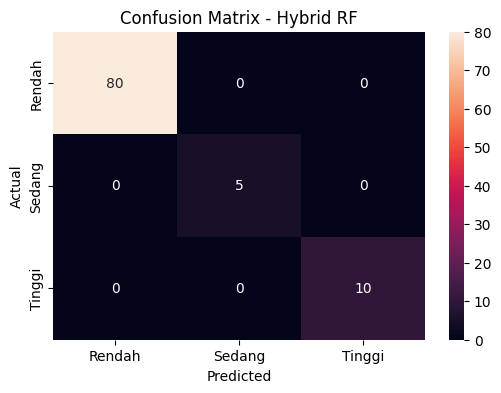

In [10]:
cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid RF")
plt.show()

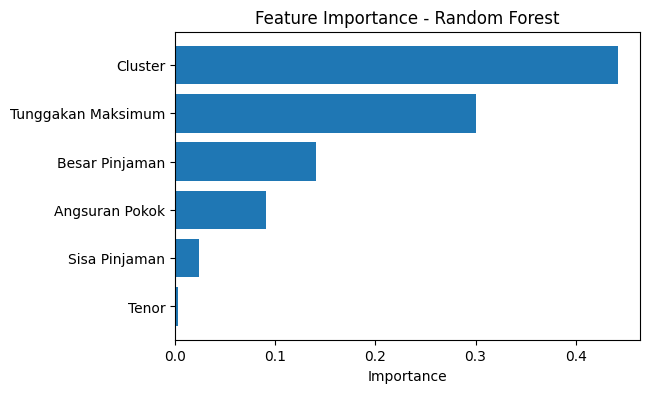

In [11]:
importance = pd.DataFrame({
    'Fitur': X2.columns,
    'Importance': rf2.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(6,4))
plt.barh(importance['Fitur'], importance['Importance'])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

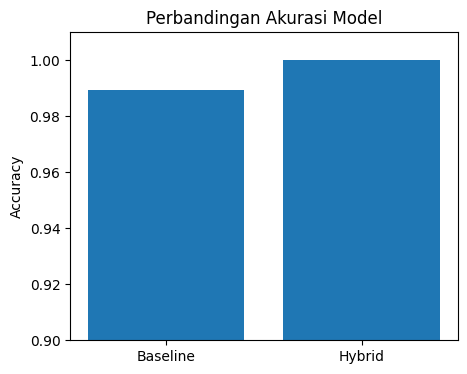

In [12]:
models = ['Baseline', 'Hybrid']
accuracy = [test_acc1, test_acc2]

plt.figure(figsize=(5,4))
plt.bar(models, accuracy)
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.01)
plt.show()

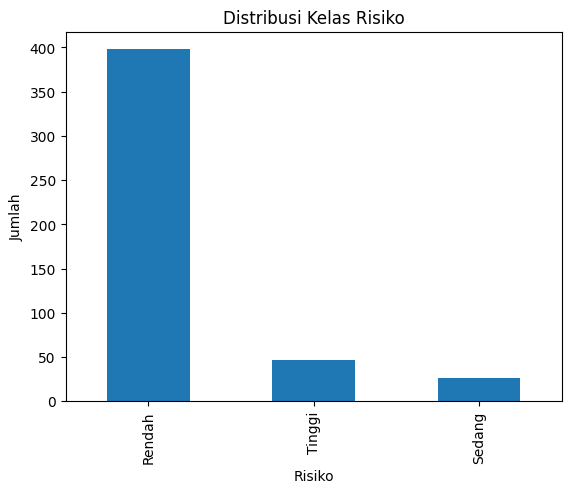

In [13]:
df['Risiko'].value_counts().plot(kind='bar')
plt.title("Distribusi Kelas Risiko")
plt.xlabel("Risiko")
plt.ylabel("Jumlah")
plt.show()

In [14]:
import os
import joblib

os.makedirs('model', exist_ok=True)

joblib.dump(rf2, 'model/random_forest_model1.pkl')

print("Model Hybrid RF berhasil disimpan!")

Model Hybrid RF berhasil disimpan!


In [15]:
print(importance)

                Fitur  Importance
3               Tenor    0.002543
1       Sisa Pinjaman    0.023929
2      Angsuran Pokok    0.090857
0      Besar Pinjaman    0.140374
4  Tunggakan Maksimum    0.300098
5             Cluster    0.442198


In [16]:
print(df['Risiko'].value_counts())

Risiko
Rendah    398
Tinggi     47
Sedang     26
Name: count, dtype: int64
